In [2]:
from sentence_transformers import SentenceTransformer, util
from sentence_transformers.util import cos_sim
import pandas as pd
import numpy as np
from tqdm import tqdm
import json
from sklearn.model_selection import train_test_split

In [3]:
import matplotlib.pyplot as plt
import numpy as np

In [6]:
from datasets import load_dataset

In [7]:
baseline_path = 'models/rusts_baseline_0913' 
curriculum_path = 'models/rusts_curriculum_0914/final_model'

baseline_model = SentenceTransformer(baseline_path)
print(f" Baseline модель загружена: {baseline_path}")

curriculum_model = SentenceTransformer(curriculum_path)
print(f" Curriculum модель загружена: {curriculum_path}")

The tokenizer you are loading from 'models/rusts_baseline_0913' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


 Baseline модель загружена: models/rusts_baseline_0913


The tokenizer you are loading from 'models/rusts_curriculum_0914/final_model' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


 Curriculum модель загружена: models/rusts_curriculum_0914/final_model


In [9]:
dataset_test = load_dataset("mteb/RuSTSBenchmarkSTS", split="test")

print(f" Загружено {len(dataset_test)} тестовых примеров")
print(f"  Пример: {dataset_test[0]}")

test_examples = []
for row in tqdm(dataset_test, desc="Processing test set"):
    s1 = row.get('sentence1') or row.get('text_1')
    s2 = row.get('sentence2') or row.get('text_2')
    score = row.get('similarity_score') or row.get('score') or row.get('label')
    
    if s1 and s2 and score is not None:
         test_examples.append({
            'query': s1,
            'passage': s2,
            'gold_score': float(score)
        })

df_test = pd.DataFrame(test_examples)

 Загружено 1264 тестовых примеров
  Пример: {'sentence1': 'Девушка укладывает волосы.', 'sentence2': 'Девушка расчесывает волосы.', 'score': 2.5}


Processing test set: 100%|██████████████████████████████████████████████████████| 1264/1264 [00:00<00:00, 50338.98it/s]


Вычмсляем представления:

In [ ]:
test_qrels = {}   
corpus_map = {}  
queries_map = {}  

idx_counter = 0
for row in tqdm(dataset_test, desc="Processing data"):
    s1 = row.get('sentence1') or row.get('text_1')
    s2 = row.get('sentence2') or row.get('text_2')
    score = row.get('similarity_score') or row.get('score') or row.get('label')
    
    if not (s1 and s2 and score is not None):
        continue
        
    threshold = 3.0 if score > 1.0 else 0.6
    
    qid = f"q_{idx_counter}"
    did = f"d_{idx_counter}"
    
    corpus_map[did] = s2
    
    if score >= threshold:
        queries_map[qid] = s1
        test_qrels[qid] = [did] 
    
    idx_counter += 1

print(f"✓ Queries (задач поиска): {len(queries_map)}")
print(f"✓ Corpus (база документов): {len(corpus_map)}")


In [ ]:
def calculate_ndcg_at_k(ranked_list, relevant_docs, k=10):
    dcg = 0.0
    idcg = 0.0
    for i, doc_id in enumerate(ranked_list[:k]):
        if doc_id in relevant_docs:
            dcg += 1.0 / np.log2(i + 2)
    for i in range(min(len(relevant_docs), k)):
        idcg += 1.0 / np.log2(i + 2)
    return dcg / idcg if idcg > 0 else 0.0

In [ ]:
def calculate_mrr(ranked_list, relevant_docs):
    for i, doc_id in enumerate(ranked_list):
        if doc_id in relevant_docs:
            return 1.0 / (i + 1)
    return 0.0

In [ ]:
def calculate_map_at_k(ranked_list, relevant_docs, k=10):
    score = 0.0
    num_relevant = 0
    for i, doc_id in enumerate(ranked_list[:k]):
        if doc_id in relevant_docs:
            num_relevant += 1
            score += num_relevant / (i + 1)
    return score / min(len(relevant_docs), k) if relevant_docs else 0.0

In [ ]:
def calculate_recall_at_k(ranked_list, relevant_docs, k=10):
    if not relevant_docs: return 0.0
    found = sum(1 for doc_id in ranked_list[:k] if doc_id in relevant_docs)
    return found / len(relevant_docs)

In [ ]:
def evaluate_model(model, model_name):
    print(f"\n{'='*60}")
    print(f"Оцениваем: {model_name}")
    print(f"{'='*60}")
    
    corpus_ids = list(corpus_map.keys())
    corpus_texts = [f"passage: {corpus_map[doc_id]}" for doc_id in corpus_ids]
    
    print("  Encoding corpus...")
    corpus_embeddings = model.encode(
        corpus_texts,
        convert_to_tensor=True,
        show_progress_bar=True
    )
    
    ndcg_at_10_scores = []
    ndcg_at_5_scores = []
    mrr_scores = []
    map_at_10_scores = []
    recall_at_10_scores = []
    recall_at_5_scores = []
    
    print("  Evaluating queries...")
    
    for query_id, query_text in tqdm(queries_map.items(), desc=f"  {model_name}"):
        query_embedding = model.encode(
            f"query: {query_text}",
            convert_to_tensor=True
        )

        similarities = util.cos_sim(query_embedding, corpus_embeddings)[0]
        
        ranked_indices = similarities.argsort(descending=True).cpu().tolist()
        ranked_doc_ids = [corpus_ids[idx] for idx in ranked_indices]
        
        relevant_docs = test_qrels[query_id]
        
        ndcg_at_10_scores.append(calculate_ndcg_at_k(ranked_doc_ids, relevant_docs, k=10))
        ndcg_at_5_scores.append(calculate_ndcg_at_k(ranked_doc_ids, relevant_docs, k=5))
        mrr_scores.append(calculate_mrr(ranked_doc_ids, relevant_docs))
        map_at_10_scores.append(calculate_map_at_k(ranked_doc_ids, relevant_docs, k=10))
        recall_at_10_scores.append(calculate_recall_at_k(ranked_doc_ids, relevant_docs, k=10))
        recall_at_5_scores.append(calculate_recall_at_k(ranked_doc_ids, relevant_docs, k=5))
    
    results = {
        'NDCG@10': np.mean(ndcg_at_10_scores),
        'NDCG@5': np.mean(ndcg_at_5_scores),
        'MRR': np.mean(mrr_scores),
        'MAP@10': np.mean(map_at_10_scores),
        'Recall@10': np.mean(recall_at_10_scores),
        'Recall@5': np.mean(recall_at_5_scores)
    }
    
    return results

In [11]:
baseline_results = evaluate_model(baseline_model, "BASELINE")
curriculum_results = evaluate_model(curriculum_model, "CURRICULUM")

print("\n" + "=" * 80)
print(f"{'Metric':<15} {'Baseline':<15} {'Curriculum':<15} {'Diff':<15} {'Improv %':<15}")
print("-" * 80)

for metric in baseline_results.keys():
    b_val = baseline_results[metric]
    c_val = curriculum_results[metric]
    diff = c_val - b_val
    pct = (diff / b_val * 100) if b_val > 0 else 0
    
    print(f"{metric:<15} {b_val:<15.4f} {c_val:<15.4f} {diff:<+15.4f} {pct:+.2f}%")

Processing data: 100%|██████████████████████████████████████████████████████████| 1264/1264 [00:00<00:00, 46714.66it/s]

✓ Queries (задач поиска): 714
✓ Corpus (база документов): 1157

Оцениваем: BASELINE
  Encoding corpus...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

  Evaluating queries...


  BASELINE: 100%|███████████████████████████████████████████████████████████████████| 714/714 [00:05<00:00, 123.70it/s]


Оцениваем: CURRICULUM
  Encoding corpus...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

  Evaluating queries...


  CURRICULUM: 100%|█████████████████████████████████████████████████████████████████| 714/714 [00:05<00:00, 129.63it/s]


Metric          Baseline        Curriculum      Diff            Improv %       
--------------------------------------------------------------------------------
NDCG@10         0.7788          0.7801          +0.0012         +0.16%
NDCG@5          0.7616          0.7628          +0.0012         +0.16%
MRR             0.7453          0.7469          +0.0016         +0.22%
MAP@10          0.7417          0.7433          +0.0016         +0.22%
Recall@10       0.8950          0.8950          +0.0000         +0.00%
Recall@5        0.8431          0.8431          +0.0000         +0.00%


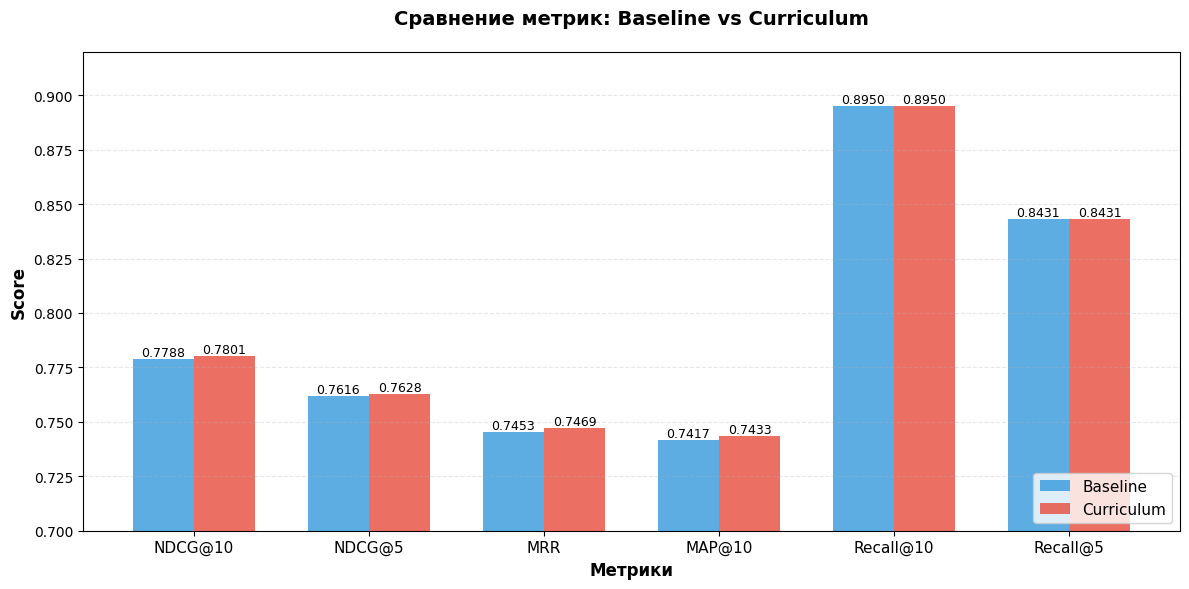

In [5]:
metrics = ['NDCG@10', 'NDCG@5', 'MRR', 'MAP@10', 'Recall@10', 'Recall@5']
baseline_scores = [0.7788, 0.7616, 0.7453, 0.7417, 0.8950, 0.8431]
curriculum_scores = [0.7801, 0.7628, 0.7469, 0.7433, 0.8950, 0.8431]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, baseline_scores, width, label='Baseline', alpha=0.8, color='#3498db')
bars2 = ax.bar(x + width/2, curriculum_scores, width, label='Curriculum', alpha=0.8, color='#e74c3c')

ax.set_xlabel('Метрики', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Сравнение метрик: Baseline vs Curriculum', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0.7, 0.92)
ax.grid(axis='y', alpha=0.3, linestyle='--')

def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}',
                ha='center', va='bottom', fontsize=9)

add_value_labels(bars1)
add_value_labels(bars2)

plt.tight_layout()
plt.show()